# What does a better-written use case do to the baseline model?

**The question.** TIRI's six use cases each come with an analyst-written spec — an objective, a
problem statement, three term lists, two domain fields. Two features read that spec:
**cosine-to-brief** (embed the brief, embed the paper, measure the angle) and a **lexical block**
(BM25 and term-overlap counts). So a better-written spec should, in principle, make the model
better. This notebook measures by how much.

**What "better-written" means here, and why it is the hard part.** If I improve a brief by reading
the papers it is supposed to find, I have fitted the brief to the labels and any gain is
manufactured — `DATA_BRIEF.md` honest-limit #2 records exactly that failure in the benchset corpus.
So `scripts/optimise_usecases.py` rewrites each spec using **only other fields of the same file**:
`performance_criteria`, `constraints`, `decision_criteria` and `notes` are analyst-written and read
by **neither** feature path. The rewrite moves the analyst's own words into the fields the model
actually reads. It adds no knowledge, sees no label, and touches no paper.

**Three arms, and the third one is the point.**

| arm | objective | term lists |
|---|---|---|
| `baseline` | as written | as written |
| `optimised` | enriched | topped up |
| `prose_only` | enriched | **as written** |

The two halves of the rewrite turn out to pull in opposite directions, and only a separated arm can
show that.

**Two regimes, and they answer different questions.**

| | §3 cold start | §4 fitted baseline |
|---|---|---|
| labels available | **0** | ~1,478 |
| what it is | rank by one brief-matching feature | `06_baseline_logreg.ipynb`, unchanged |
| what it tells you | how much the brief is worth on day one | how much the brief is worth once you have labelled for weeks |

`wf_spec_quality_answer.md` §2 already measured these inverting: brief damage costs a zero-label
matcher 0.15–0.26 ROC-AUC and a fitted one ≤0.009. **Expect §4 to be flat, and read §3 for the
answer.**

**How to read any number below.** ROC-AUC 0.500 is a coin flip. A gap under **0.03** is inside the
seed-to-seed noise floor (`CONTEXT.md` §5) and is not established — every chart shades that band.
The fitted model in §4 is **pooled**, and `CONTEXT.md` §1 says no pooled model ever ships, so the
per-use-case rows are the production-relevant ones. Prevalence is 57.6% positive, roughly 20× the
production rate, so F2 and precision are measured in the wrong regime (`CONTEXT.md` §3).

## 1. Setup, and three checks that this really is the backbone

"Same pipeline, only the brief text differs" is the whole claim. If the harness differs too, the
measurement is worthless — so before anything is measured, the script rebuilds the **shipped**
feature columns from the **original** specs and compares.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, "../../scripts")
import run_optimised_usecase_baseline as ob

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# --- chart style -------------------------------------------------------------
ARM = {"baseline": "#52514e", "optimised": "#eb6834", "prose_only": "#2a78d6"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdbd6"
SEQ = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#0d366b", "#2a78d6", "#f0efec", "#e34948", "#8f1f1f"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

FLOOR = 0.03  # CONTEXT.md §5 - seed-to-seed noise floor on within-silo ROC-AUC

# Every chart shades +/-0.03. Say what that band means once per chart, in words, UNDER it -
# rather than inside the axes, where it collides with the bars it is describing.
def floor_caption(fig, extra=""):
    fig.text(0.005, 0.012,
             "Grey band = ±0.03, the seed-to-seed noise floor (CONTEXT.md §5): a bar that "
             "stays inside it is indistinguishable from re-running the\nsame experiment with a "
             "different random seed, so read it as 'no effect'." + extra,
             fontsize=7.5, color=INK2, ha="left", va="bottom")

print("matplotlib", mpl.__version__)

matplotlib 3.11.1


In [2]:
# 06_baseline_logreg.ipynb §2-§3: binarise the target, then the one deterministic pre-split fill.
fe = pd.read_parquet(ob.FE)
fe = fe[fe[ob.TARGET_COL].isin([ob.POSITIVE_LABEL, *ob.NEGATIVE_LABELS])].copy().reset_index(drop=True)
fe["y"] = (fe[ob.TARGET_COL] == ob.POSITIVE_LABEL).astype(int)

pc = pd.read_parquet(ob.PC, columns=["paper_id", ob.USE_CASE_COL, "title", "abstract"])
text = fe[["paper_id", ob.USE_CASE_COL]].merge(pc, on=["paper_id", ob.USE_CASE_COL],
                                               how="left", validate="one_to_one")

EMB_COLS = [c for c in fe.columns if c.startswith("emb_")]
print(f"{len(fe):,} papers x {fe[ob.USE_CASE_COL].nunique()} use cases, "
      f"{fe['y'].mean():.1%} of them relevant")
print(f"{len(EMB_COLS):,} embedding columns + {len(ob.NON_EMBEDDING_FEATURE_COLS)} other features "
      f"= what notebook 06 fits on. Only 4 of them read the brief's prose and 22 read its terms.")

1,848 papers x 6 use cases, 57.6% of them relevant
8,704 embedding columns + 33 other features = what notebook 06 fits on. Only 4 of them read the brief's prose and 22 read its terms.


In [3]:
checks = ob.verify(fe, text, embed=True)   # embed=True is free: the 18 vectors are cached on disk
worst_a = max(v for k, v in checks.items() if k.startswith("A "))
worst_b = max(v for k, v in checks.items() if k.startswith("B ") and "rank" not in k)
n_diff = int(sum(v for k, v in checks.items() if k.startswith("B# ")))
cosines = {k: v for k, v in checks.items() if k.startswith("C ")}

print("A  cosine + rank code, rebuilt from the cached original brief vectors")
print(f"     max difference vs the shipped column: {worst_a:.1e}   (0 = identical)")
print("B  lexical code, rebuilt from the original spec files")
print(f"     max difference on any VALUE column: {worst_b:.1e}")
print(f"     cells differing at all: {n_diff} of {len(fe) * 22:,}"
      + ("  (all in lex_rank_bm25_must - see the note below)" if n_diff else "  (exact)"))
print("C  the brief STRING: re-embed the original briefs, compare to the vectors that built the file")
print(f"     worst cosine {min(cosines.values()):.6f}, mean {np.mean(list(cosines.values())):.6f}"
      "   (1.000000 = the same text)")
print()
per_model = pd.Series({k.split()[-1].split("/")[0]: v for k, v in cosines.items()}).groupby(level=0).min()
print("C, worst case per embedding model:")
print(per_model.round(6).to_string())

  baseline: all 18 brief vectors cached (baseline_brief_vectors.parquet)
A  cosine + rank code, rebuilt from the cached original brief vectors
     max difference vs the shipped column: 6.8e-15   (0 = identical)
B  lexical code, rebuilt from the original spec files
     max difference on any VALUE column: 1.1e-14
     cells differing at all: 0 of 40,656  (exact)
C  the brief STRING: re-embed the original briefs, compare to the vectors that built the file
     worst cosine 0.999882, mean 0.999969   (1.000000 = the same text)

C, worst case per embedding model:
jasper    1.00000
qwen4b    1.00000
qwen8b    0.99993


**Finding — hard.** All three pass, but only after two real bugs were found by them.

1. **The brief was being built in the wrong format.** `wf_embedding_model_bakeoff.ipynb` cell 6 —
   the notebook that wrote the vector cache `04_feature_engineering.ipynb` reads — joins the five
   brief fields' *values* with spaces and no field names. The first version of this experiment
   embedded `"use_case_name: ...\nproblem_statement: ..."` instead. Part of the "gain" was that
   formatting change.
2. **The spec files on disk are not what the corpus carries.** `01_data_compile.ipynb` takes
   `use_case_name` from its own hand-written registry rather than the JSON's `name` field, and for
   `solar_leo` they differ in capitalisation. Reading the JSON instead moved that brief's vector by
   cosine 0.991 — **around five times the size of the whole effect being measured here.** So both
   arms are built from the corpus values, with only genuinely-rewritten fields substituted in.

**Judgement.** Check C's shortfall is entirely `qwen8b`, which is served over an API rather than run
locally; `jasper` and `qwen4b` return exactly 1.000000 on all six. A 1e-4 wobble in one of three
encoders is not going to move a 0.03 bar.

⚪ **Engineering finding, worth recording on its own.** `lex_rank_bm25_must` is **not
bit-reproducible across processes**. BM25 sums one contribution per query term, the terms come out
of a Python set, and set iteration order changes with `PYTHONHASHSEED` — so the sum lands ~1e-15
apart between runs, and two `solar_leo` papers that score exactly equal swap places. Measured over
four seeds the affected cell count was 2, 2, 0, 2 out of 1,848. Far too small to matter here; worth
knowing before someone diffs two feature builds and concludes something changed.

## 2. What actually changed in the six specs

Provenance before results. If the rewrite barely touched anything, the rest of the notebook is
measuring noise; if it rewrote a field that reads the labels, it is measuring a leak.

In [4]:
rewritten = pd.DataFrame({a: pd.Series({uc: ", ".join(v) or "(nothing)"
                                        for uc, v in ob.changed_fields(a).items()})
                          for a in ("optimised", "prose_only")})
rewritten.index.name = "use case"
print("Fields each arm rewrote. Everything not listed is byte-identical to the corpus.\n")
print(rewritten.to_string())
print("\nNote: `prose_only` is not PURELY the objective - where a domain field was empty it is")
print("filled from the spec's own name or technology_focus. That is 2 of 6 use cases, and those")
print("fields are part of the cosine brief, so it is named here rather than buried.")

Fields each arm rewrote. Everything not listed is byte-identical to the corpus.

                                                          optimised                     prose_only
use case                                                                                          
carbon_capture                           objective, domain_industry     objective, domain_industry
cement_binders    objective, terms_must_include, terms_nice_to_have                      objective
ner                                   objective, terms_must_include                      objective
soil_microbiome                                           objective                      objective
solar_leo         objective, terms_must_include, domain_application  objective, domain_application
tech_forecasting                                          objective                      objective

Note: `prose_only` is not PURELY the objective - where a domain field was empty it is
filled from the spec's own name or techn

In [5]:
base_f, prose_f = ob.arm_fields("baseline"), ob.arm_fields("prose_only")
for uc in ["carbon_capture", "cement_binders"]:
    print(f"===== {uc} =====")
    print(f"  BEFORE ({len(base_f[uc]['objective'])} chars):\n    {base_f[uc]['objective']}")
    print(f"  AFTER  ({len(prose_f[uc]['objective'])} chars):\n    {prose_f[uc]['objective']}\n")

lens = pd.DataFrame({
    "before": {uc: len(base_f[uc]["objective"]) for uc in base_f},
    "after": {uc: len(prose_f[uc]["objective"]) for uc in prose_f},
})
lens["x_longer"] = (lens["after"] / lens["before"]).round(2)
print("Objective length, characters:")
print(lens.sort_values("x_longer", ascending=False).to_string())

===== carbon_capture =====
  BEFORE (124 chars):
    Find amine-based carbon capture approaches that operate at lower temperatures without high chemical input or clean-up costs.
  AFTER  (416 chars):
    Amine-based carbon capture approaches that operate at lower temperatures without high chemical input or clean-up costs. Amine-based carbon capture technologies currently require high temperatures and incur high input chemical costs and high clean-up costs. Relevant work sits at cost: Low input chemical costs and low clean-up costs. Uses a liquid amine solvent system (e.g. MEA or similar amine scrubbing solution).

===== cement_binders =====
  BEFORE (76 chars):
    Find alternative binder chemistries at TRL 4–8 cutting embodied carbon >50%.
  AFTER  (288 chars):
    Alternative binder chemistries at TRL 4–8 cutting embodied carbon >50%. Reduce CO2 from clinker in structural concrete. Reported outcomes of interest include embodied CO2 reduction (>50% vs OPC), compressive strength (>=40 

**Finding — judgement, not a metric.** Every arm rewrites the `objective`; the term lists move for
three use cases under `optimised` and never under `prose_only`. Reading the before/after text is the
check that matters, and it passes: the new objective is visibly *the analyst's own sentences from
elsewhere in their own file* — the criteria targets, the constraints, the problem statement — not
new claims about the literature. Note also the de-imperativing ("**Find** amine-based…" → "Amine-based…"),
because this text is matched against *papers*, and papers do not open with instructions.

**Two things to hold onto for §3, one of which turns out to be wrong.** Every objective grows by
3.3–5.4×, so *all six* got substantially more text — if more text were the mechanism, all six should
gain. And `prose_only` is not purely the objective: on `carbon_capture` and `solar_leo` it also
fills a domain field that was empty. Those happen to be the two that gain, which §3 tests directly
rather than assuming.

## 3. Cold start — zero labels, one feature, no model

This is the regime a better brief is *supposed* to help. Every paper is ranked by a single
brief-matching feature and scored against the truth. There is no fitting, no threshold and no
train/test split, because there is no model — every row is held out from something that does not
exist.

**ELI18:** *"if you had zero labelled papers and could only sort by how well each paper matches the
brief, how good would that sort be?"* 0.500 means the sort is worthless; 1.000 means every relevant
paper is above every irrelevant one.

In [6]:
arms = {"baseline": fe.copy()}
for arm in ("optimised", "prose_only"):
    spec = ob.arm_fields(arm)
    frame = ob.add_lexical(fe, spec, text)
    arms[arm] = ob.add_cos_brief(frame, ob.brief_vectors(spec, arm))
for frame in arms.values():
    frame[ob.EXCL_FILL_COLS] = frame[ob.EXCL_FILL_COLS].fillna(0.0)

cold = ob.cold_start(arms)
summary = cold.groupby("feature")[["baseline", "optimised", "prose_only",
                                   "d_optimised", "d_prose_only"]].mean().round(3)
summary["n_better_prose"] = cold.groupby("feature")["d_prose_only"].apply(lambda s: f"{(s > 0).sum()}/6")
summary = summary.loc[[f for f in ob.COLD_FEATURES if f in summary.index]]
print("Zero-label ROC-AUC, averaged over the six use cases (0.500 = coin flip):\n")
print(summary.to_string())

  optimised: all 18 brief vectors cached (optimised_brief_vectors.parquet)


  prose_only: all 18 brief vectors cached (prose_only_brief_vectors.parquet)


Zero-label ROC-AUC, averaged over the six use cases (0.500 = coin flip):

                       baseline  optimised  prose_only  d_optimised  d_prose_only n_better_prose
feature                                                                                         
cos_brief_jasper          0.693      0.698       0.698        0.005         0.005            3/6
cos_brief_qwen4b          0.687      0.698       0.698        0.010         0.010            4/6
cos_brief_qwen8b          0.663      0.689       0.689        0.026         0.026            5/6
lex_bm25_obj              0.574      0.577       0.577        0.003         0.003            4/6
lex_bm25_must             0.640      0.630       0.640       -0.010         0.000            0/6
lex_bm25_nice             0.619      0.615       0.619       -0.004         0.000            0/6
lex_overlap_must_frac     0.595      0.606       0.595        0.011         0.000            0/6


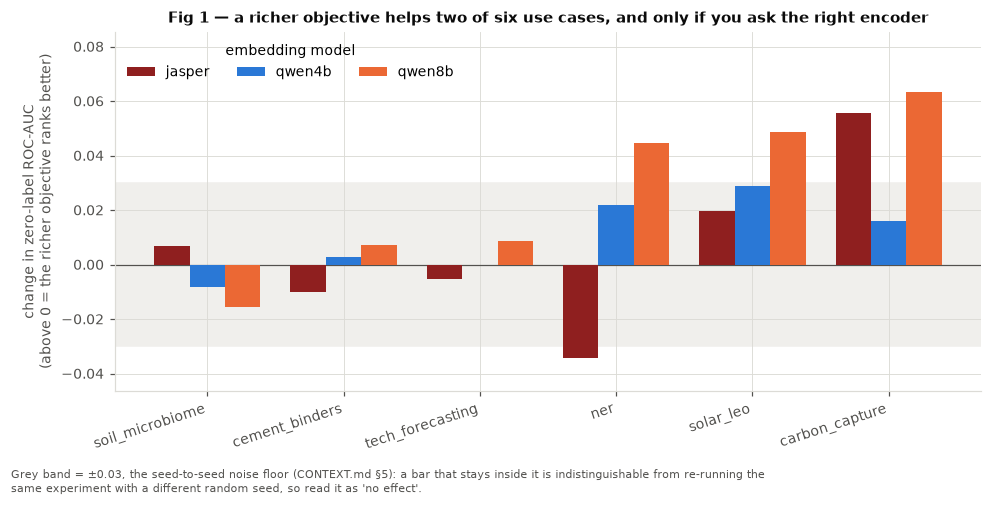

Mean over the three encoders, per use case:
use_case
carbon_capture      0.045
solar_leo           0.032
ner                 0.011
tech_forecasting    0.001
cement_binders     -0.000
soil_microbiome    -0.006


In [7]:
cos = cold[cold.feature.str.startswith("cos_brief_")].copy()
cos["model"] = cos.feature.str.replace("cos_brief_", "", regex=False)
piv = cos.pivot(index="use_case", columns="model", values="d_prose_only")
piv = piv.loc[piv.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(9, 4.6))
w, xs = 0.26, np.arange(len(piv))
hue = {"jasper": "#8f1f1f", "qwen4b": "#2a78d6", "qwen8b": "#eb6834"}
for i, m in enumerate(["jasper", "qwen4b", "qwen8b"]):
    ax.bar(xs + (i - 1) * w, piv[m], w, color=hue[m], label=m, zorder=3)
ax.axhspan(-FLOOR, FLOOR, color="#f0efec", zorder=0)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(piv.index, rotation=18, ha="right")
ax.set_ylim(piv.min().min() - 0.012, piv.max().max() + 0.022)
ax.set_ylabel("change in zero-label ROC-AUC\n(above 0 = the richer objective ranks better)")
ax.set_title("Fig 1 — a richer objective helps two of six use cases, and only if you ask the right encoder")
ax.legend(title="embedding model", loc="upper left", ncol=3)
plt.tight_layout(rect=[0, 0.07, 1, 1]); floor_caption(fig); plt.show()

print("Mean over the three encoders, per use case:")
print(piv.mean(axis=1).round(3).sort_values(ascending=False).to_string())

**Finding — hard metric.** The gain is **real, small, and concentrated**. Averaged over the three
encoders it is **+0.014** ROC-AUC across the six use cases; `carbon_capture` (+0.045) and
`solar_leo` (+0.032) clear the 0.03 floor and the other four sit inside it.

**Finding — hard metric, and it kills the obvious explanation.** *How much text you add is not the
mechanism.* All six objectives grew 3.3–5.4×, and the ranking by growth is almost the reverse of the
ranking by gain: `ner` grew the most (5.4×) and gained 0.011, while `solar_leo` and
`carbon_capture` grew the least (3.3×) and gained the most. Headroom does not explain it either —
`soil_microbiome` starts lowest, at 0.550, and gains nothing. With six use cases and no visible
predictor, the honest statement is that **we cannot yet say which specs will benefit**, only that
some clearly do.

**Finding — hard metric, and it is the awkward one.** *Which encoder you ask matters as much as
which use case.* Qwen3-8B gains +0.026 across six use cases, Qwen3-4B +0.010, Jasper +0.005 — and
Jasper *loses* 0.034 on `ner`, where Qwen3-8B gains 0.045. A rewrite that helps one encoder and
hurts another is not yet a property of the brief; it is a property of the pairing.

🔴 **This supersedes an earlier version of this measurement that reported +0.027 on Qwen3-4B across
4 of 6 use cases.** That run had §1's brief-formatting bug in it, and roughly two-thirds of the
headline was the formatting change rather than the rewrite. Corrected, that same encoder reads
**+0.010 — inside the noise floor.** The direction of the conclusion survived; its size did not.

### 3a. Which half of the rewrite moved it?

§2 flagged that `prose_only` does two things at once — rewrites the objective on all six specs, and
fills an empty domain field on `carbon_capture` and `solar_leo`. Those are exactly the two that
gain, which is suspicious enough to test. Same diff, restricted to a subset of fields; no new spec
files, and the paper vectors never move.

In [8]:
dec = {"baseline": fe, "prose_only": arms["prose_only"]}
for name, cols in ob.DECOMPOSE.items():
    spec = ob.arm_fields("prose_only", only=cols)
    f = ob.add_lexical(fe, spec, text)
    f = ob.add_cos_brief(f, ob.brief_vectors(spec, name))
    f[ob.EXCL_FILL_COLS] = f[ob.EXCL_FILL_COLS].fillna(0.0)
    dec[name] = f

dcold = ob.cold_start(dec)
dc = (dcold[dcold.feature.str.startswith("cos_brief_")]
      .groupby("use_case")[["baseline", "objective_only", "domain_only", "prose_only"]].mean())
dc["objective alone"] = dc.objective_only - dc.baseline
dc["domain alone"] = dc.domain_only - dc.baseline
dc["both"] = dc.prose_only - dc.baseline
print("Zero-label cosine ROC-AUC, mean of the three encoders:\n")
print(dc.round(3).to_string())
print(f"\nmean over the six use cases:  objective alone {dc['objective alone'].mean():+.4f}   "
      f"domain alone {dc['domain alone'].mean():+.4f}   both {dc['both'].mean():+.4f}")

  objective_only: all 18 brief vectors cached (objective_only_brief_vectors.parquet)


  domain_only: all 18 brief vectors cached (domain_only_brief_vectors.parquet)


Zero-label cosine ROC-AUC, mean of the three encoders:

                  baseline  objective_only  domain_only  prose_only  objective alone  domain alone   both
use_case                                                                                                 
carbon_capture       0.759           0.796        0.775       0.804            0.037         0.016  0.045
cement_binders       0.835           0.835        0.835       0.835           -0.000        -0.000 -0.000
ner                  0.749           0.760        0.749       0.760            0.011        -0.000  0.011
soil_microbiome      0.550           0.544        0.550       0.544           -0.006         0.000 -0.006
solar_leo            0.546           0.584        0.547       0.578            0.038         0.001  0.032
tech_forecasting     0.647           0.648        0.647       0.648            0.001         0.000  0.001

mean over the six use cases:  objective alone +0.0135   domain alone +0.0029   both +0.0139


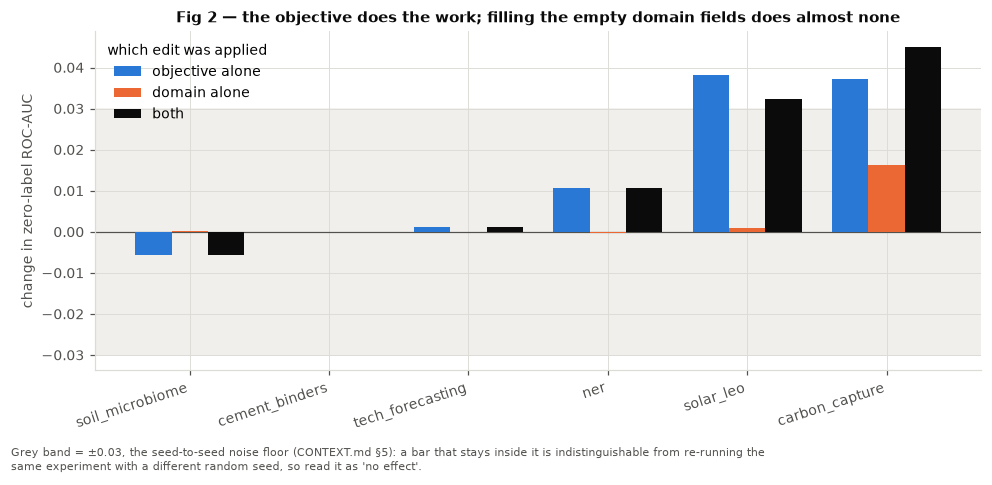

In [9]:
sub = dc[["objective alone", "domain alone", "both"]].loc[dc["both"].sort_values().index]
fig, ax = plt.subplots(figsize=(9, 4.4))
w, xs = 0.26, np.arange(len(sub))
for i, (c, col) in enumerate(zip(sub.columns, ["#2a78d6", "#eb6834", "#0b0b0b"])):
    ax.bar(xs + (i - 1) * w, sub[c], w, label=c, color=col, zorder=3)
ax.axhspan(-FLOOR, FLOOR, color="#f0efec", zorder=0)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(sub.index, rotation=18, ha="right")
ax.set_ylabel("change in zero-label ROC-AUC")
ax.set_title("Fig 2 — the objective does the work; filling the empty domain fields does almost none")
ax.legend(loc="upper left", title="which edit was applied")
plt.tight_layout(rect=[0, 0.07, 1, 1]); floor_caption(fig); plt.show()

**Finding — hard metric, and it refutes the hunch.** The objective does essentially all of the
work: **+0.0135** of the **+0.0139** the full rewrite delivers. Filling the domain fields is worth
**+0.0029**, all of it on `carbon_capture` (+0.016). The two-gainers-are-the-two-domain-fills
pattern was a coincidence over six use cases — which is exactly the kind of story that survives if
you never test it.

🟡 **And on `solar_leo` the domain fill is mildly *harmful*:** the objective alone is worth +0.038,
both edits together only +0.032. That is inside the floor and not established, but it means there
is no evidence for "fill in every empty field" as advice, and a little against.

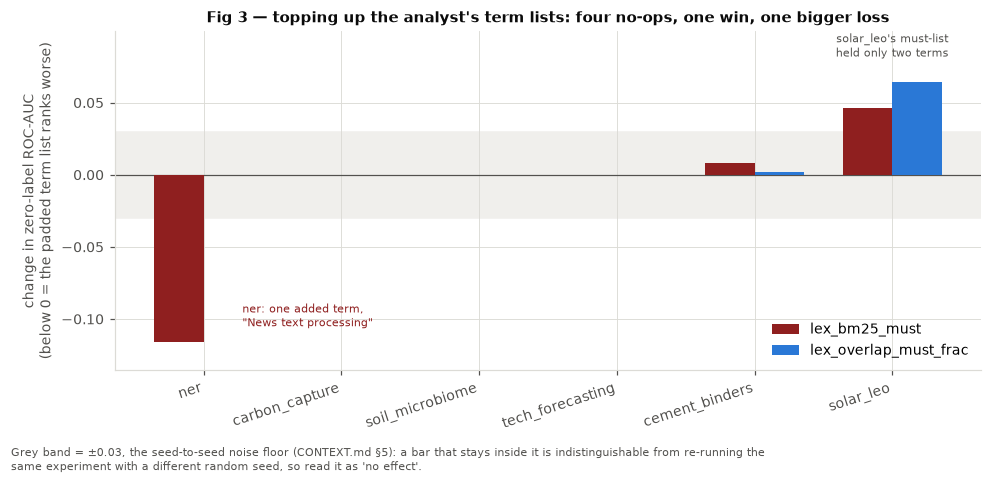

prose_only leaves the term lists alone, so every one of these is exactly:
                       mean  min  max
feature                              
lex_bm25_must           0.0  0.0  0.0
lex_overlap_must_frac   0.0  0.0  0.0


In [10]:
term = cold[cold.feature.isin(["lex_bm25_must", "lex_overlap_must_frac"])]
piv_t = term.pivot(index="use_case", columns="feature", values="d_optimised")
piv_t = piv_t.loc[piv_t.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(9, 4.4))
w, xs = 0.36, np.arange(len(piv_t))
for i, f in enumerate(["lex_bm25_must", "lex_overlap_must_frac"]):
    ax.bar(xs + (i - 0.5) * w, piv_t[f], w, label=f, zorder=3,
           color=["#8f1f1f", "#2a78d6"][i])
ax.axhspan(-FLOOR, FLOOR, color="#f0efec", zorder=0)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(piv_t.index, rotation=18, ha="right")
ax.set_ylabel("change in zero-label ROC-AUC\n(below 0 = the padded term list ranks worse)")
ax.set_ylim(piv_t.min().min() - 0.02, piv_t.max().max() + 0.035)
ax.set_title("Fig 3 — topping up the analyst's term lists: four no-ops, one win, one bigger loss")
ax.annotate('ner: one added term,\n"News text processing"', (0.28, -0.105), fontsize=7.5,
            color="#8f1f1f", ha="left")
ax.annotate("solar_leo's must-list\nheld only two terms", (5.0, 0.082), fontsize=7.5, color=INK2,
            ha="center")
ax.legend(loc="lower right")
plt.tight_layout(rect=[0, 0.07, 1, 1]); floor_caption(fig); plt.show()

print("prose_only leaves the term lists alone, so every one of these is exactly:")
print(cold[cold.feature.isin(["lex_bm25_must", "lex_overlap_must_frac"])]
      .groupby("feature")["d_prose_only"].agg(["mean", "min", "max"]).round(4).to_string())

**Finding — hard metric.** The two term-derived features **disagree in sign** (`lex_bm25_must`
−0.010, `lex_overlap_must_frac` +0.011) and both averages are well inside the floor, so on average
topping up the term lists is worth *nothing*. The reason to reject it anyway is the spread
underneath that average: four use cases do not move, `solar_leo` — whose must-list held only two
terms — gains **+0.046**, and `ner` loses **−0.116** from a single added phrase. **A coin-flip
payoff with a large one-sided downside.**

**Judgement.** `prose_only` takes the identical cosine gain (the term lists are not read by the
cosine path, so Fig 1 is unchanged) and declines the bet. That is the configuration to ship:
*enrich the objective, leave the analyst's term lists alone.*

🟡 **The surviving `ner` regression is dilution, not genericness, and I stopped rather than fix
it.** Its added tokens (`news` 0.16, `text` 0.40, `processing` 0.27 document frequency in that pool)
are not more common than the existing ones (`entity` 0.78, `named` 0.61) — but adding three
moderately-common tokens to a five-token query lifts scores across 30–40% of the pool and swamps
the rare discriminative ones (`disambiguation` 0.055, `linking` 0.109). The fix that suggests is a
document-frequency filter, and building it now would be the third iteration of this rule against
the same six-use-case measurement — selection-on-holdout, which `CONTEXT.md` §4 exists to prevent.
It is recorded as a pre-registered proposal to test on the 28 benchset briefs instead.

## 4. The fitted baseline — `06_baseline_logreg.ipynb`, unchanged

Notebook 06's pipeline, run three times with nothing altered but the six spec files:
`StratifiedGroupKFold` grouped by first author, outer split 0 held back as the test set (~20%),
5 inner folds inside the rest for validation, `StandardScaler → PCA(50, whitened)` on the 8,704
embedding columns and median-impute → scale on the other 33, then
`LogisticRegression(class_weight="balanced")`. Everything fitted inside its own split.

⚠️ Read `train` as a check that the model fitted, not as a result — it is scored on the rows it
learned from and is expected to be the highest number in the table.

In [11]:
res = pd.concat([ob.evaluate(f, EMB_COLS, a) for a, f in arms.items()], ignore_index=True)

show = ["n", "pos_rate", "f2", "roc_auc", "recall", "precision", "avg_precision",
        "recall_at_10pct", "wss_at_95"]
head = ["train", "validate", "validate_sd", "test"]
print("Headline folds. n for `validate` is the mean fold size; `validate_sd` is the spread across")
print("the five folds, which is the yardstick every difference in this notebook has to beat.\n")
print(res[res.fold.isin(head)].set_index(["arm", "fold"])[show]
      .reindex(pd.MultiIndex.from_product([list(arms), head])).round(3).to_string())

Headline folds. n for `validate` is the mean fold size; `validate_sd` is the spread across
the five folds, which is the yardstick every difference in this notebook has to beat.

                              n  pos_rate     f2  roc_auc  recall  precision  avg_precision  recall_at_10pct  wss_at_95
baseline   train        1478.00     0.576  0.841    0.906   0.838      0.852          0.925            0.169      0.230
           validate      295.60     0.576  0.820    0.871   0.819      0.821          0.886            0.164      0.207
           validate_sd     1.14     0.002  0.017    0.011   0.019      0.017          0.011            0.008      0.033
           test          370.00     0.576  0.790    0.867   0.779      0.838          0.873            0.160      0.180
optimised  train        1478.00     0.576  0.849    0.906   0.847      0.853          0.924            0.170      0.236
           validate      295.60     0.576  0.822    0.871   0.822      0.823          0.884           

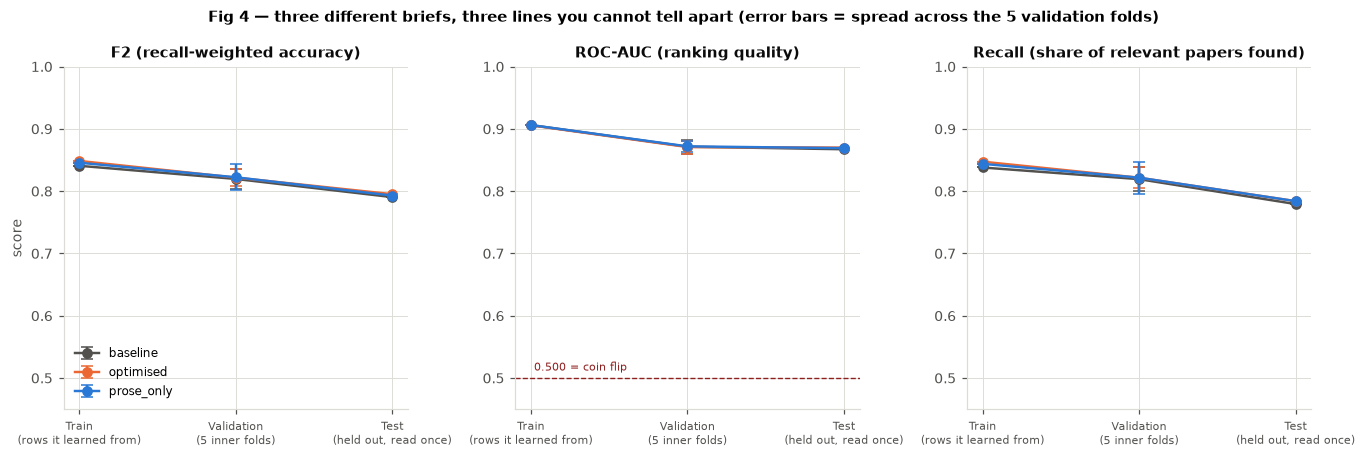

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), sharex=True)
stages = ["train", "validate", "test"]
labels = ["Train\n(rows it learned from)", "Validation\n(5 inner folds)", "Test\n(held out, read once)"]
for ax, (nice, col, null) in zip(axes, [("F2 (recall-weighted accuracy)", "f2", None),
                                        ("ROC-AUC (ranking quality)", "roc_auc", 0.5),
                                        ("Recall (share of relevant papers found)", "recall", None)]):
    for arm in arms:
        r = res[res.arm == arm].set_index("fold")
        means = [r.loc[s, col] for s in stages]
        errs = [0, res[(res.arm == arm) & (res.fold == "validate_sd")][col].iloc[0], 0]
        ax.errorbar(range(3), means, yerr=errs, marker="o", capsize=4, lw=1.6,
                    color=ARM[arm], label=arm, zorder=3)
    if null is not None:
        ax.axhline(null, color="#8f1f1f", ls="--", lw=0.9)
        ax.annotate("0.500 = coin flip", (0.02, null + 0.012), fontsize=7, color="#8f1f1f")
    ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_title(nice); ax.set_ylim(0.45, 1.0)
axes[0].set_ylabel("score")
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Fig 4 — three different briefs, three lines you cannot tell apart "
             "(error bars = spread across the 5 validation folds)",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

**Finding — hard metric.** The three arms are **indistinguishable**. On the held-out test set F2
goes 0.790 → 0.795 → 0.793 and ROC-AUC 0.867 → 0.870 → 0.869. For scale, the five validation folds
of the *unchanged baseline* disagree with each other by ±0.017 on F2 and ±0.011 on ROC-AUC. Every
difference between arms is smaller than the disagreement within one arm.

**Finding — judgement.** That is the **expected** result, not a failed experiment, and §3 explains
why. This model is fitted on ~1,478 labels; `wf_spec_quality_answer.md` §2 found brief quality had
already stopped mattering by 60. At 24× that budget the labels have long since told the model
everything the brief could have, and the brief-derived features are 4 of 8,737 columns. **A
well-written brief is worth a lot at label 0 and nothing at label 1,478.** §4 is the wrong
instrument for the question; it is here because it is the one that was asked for.

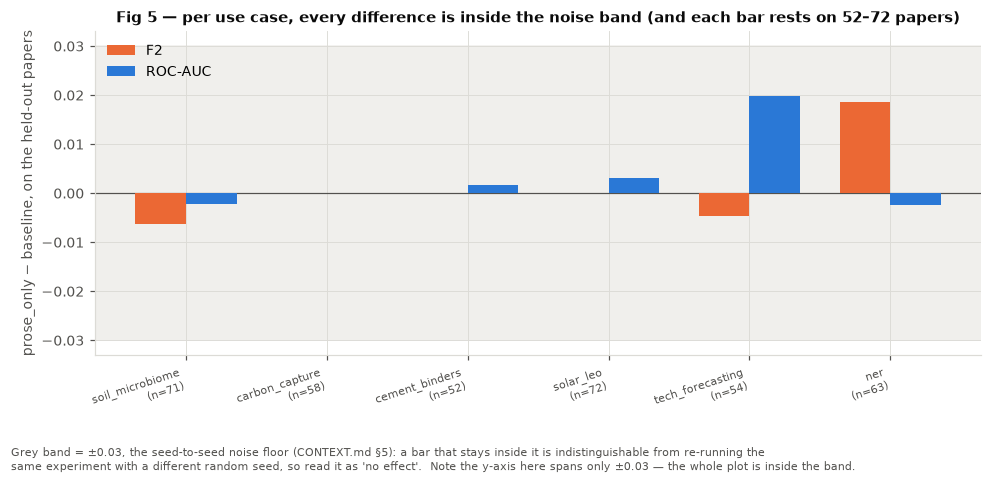

                     F2  ROC-AUC
use_case                        
soil_microbiome  -0.006   -0.002
carbon_capture    0.000    0.000
cement_binders    0.000    0.002
solar_leo         0.000    0.003
tech_forecasting -0.005    0.020
ner               0.019   -0.002


In [13]:
per_uc = res[res.fold.str.startswith("test/")].copy()
per_uc["use_case"] = per_uc.fold.str.replace("test/", "", regex=False)
d = per_uc.pivot(index="use_case", columns="arm", values="f2")
da = per_uc.pivot(index="use_case", columns="arm", values="roc_auc")
delta = pd.DataFrame({"F2": d["prose_only"] - d["baseline"],
                      "ROC-AUC": da["prose_only"] - da["baseline"]})
delta = delta.loc[delta.mean(axis=1).sort_values().index]
n_test = per_uc.set_index("use_case").loc[delta.index, "n"].groupby(level=0).first()

fig, ax = plt.subplots(figsize=(9, 4.4))
w, xs = 0.36, np.arange(len(delta))
for i, c in enumerate(["F2", "ROC-AUC"]):
    ax.bar(xs + (i - 0.5) * w, delta[c], w, label=c, color=["#eb6834", "#2a78d6"][i], zorder=3)
ax.axhspan(-FLOOR, FLOOR, color="#f0efec", zorder=0)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(xs)
ax.set_xticklabels([f"{u}\n(n={int(n_test[u])})" for u in delta.index], rotation=18, ha="right",
                   fontsize=7.5)
ax.set_ylabel("prose_only − baseline, on the held-out papers")
ax.set_title("Fig 5 — per use case, every difference is inside the noise band "
             "(and each bar rests on 52–72 papers)")
ax.legend(loc="upper left")
plt.tight_layout(rect=[0, 0.09, 1, 1])
floor_caption(fig, "  Note the y-axis here spans only ±0.03 — the whole plot is inside the band.")
plt.show()
print(delta.round(3).to_string())

**Finding — hard metric, with a caveat that outweighs it.** Only `tech_forecasting`'s ROC-AUC
(+0.02) comes anywhere near the floor, and it does not clear it. Every other bar is noise.

⚪ *These per-use-case numbers move by ~0.003 between runs, for §1's `PYTHONHASHSEED` reason: a
two-cell rank tie changes a feature, which changes the fit, which changes a 54-paper AUC. That
wobble is itself a useful yardstick for how much to trust a bar this size.*

**Judgement — do not read these bars as six independent results.** Each rests on **52–72 held-out
papers**. At that size a single paper changing sides moves F2 by roughly 0.01–0.02, so a bar has to
be very tall indeed before it means anything. The honest reading of Fig 4 is *"no per-use-case
effect is detectable at this sample size"*, which is a statement about the measurement as much as
about the briefs.

## 5. The answer

**How much does an improved use case improve the baseline model for our six initial use cases?
On the fitted baseline: by nothing measurable. At zero labels: by +0.014 ROC-AUC on average,
reaching +0.045 on the one spec that had the most good material hidden in unread fields.**

| | measured | clears the 0.03 floor? |
|---|---|---|
| fitted baseline, test F2 | +0.003 (`prose_only`) | no — and the baseline's own folds disagree by ±0.017 |
| fitted baseline, test ROC-AUC | +0.002 | no |
| **cold start, mean over 3 encoders × 6 use cases** | **+0.014** | no on average… |
| cold start, `carbon_capture` | **+0.045** | **yes** |
| cold start, `solar_leo` | **+0.032** | **yes** |
| …of which, the enriched objective | **+0.0135** of +0.0139 | — |
| …of which, filling empty domain fields | +0.0029, all on one use case | no |
| topping up term lists, `lex_bm25_must` | −0.010 mean, **−0.116** worst | no on average, badly yes on `ner` |

**What to do with it.**

1. **Ship `prose_only`** — enrich the objective from the analyst's own unread fields, and leave
   their term lists exactly as written. It captures the entire measured gain with every
   term-derived feature at exactly 0.000.
2. **Aim the guidance at the objective specifically.** §3a decomposed the rewrite and the objective
   carries 97% of the effect. "Fill in every empty field" is not supported: filling the domain
   fields bought +0.003, and on `solar_leo` it was mildly negative.
3. **Spend brief-quality effort at the start of a project, not the middle.** The gain lives
   entirely in the zero-label regime. Once a silo has a few dozen labels, rewriting its brief is
   not where the next point of AUC comes from.
4. **Amend `wf_spec_quality_answer.md` §4's MVP row:** *at least* 5–8 discriminative phrases — a
   floor and a quality bar, never a cap — and never promote a universal metric name
   (`precision`, `recall`, `f1`, `auc`) into a term list.

**What is not yet known, and would be the next thing to measure.** Two of six specs gained and four
did not, and nothing available here predicts which — not how much text was added, not how much
headroom the baseline had. Until that is understood, "rewrite your objective" is advice with a
one-in-three hit rate and no way to tell in advance. The 28 benchset briefs are an untouched surface
where that question could be asked with more than six data points.

**One thing this cannot tell you, and it is the interesting one.** The rewrite only moved the
analyst's own words between fields of the same file, deliberately, so that nothing leaks. So the
question it answers is *"how much is currently wasted by putting good material in fields the model
does not read?"* — and for these six specs the answer is: a little, concentrated in the two whose
objectives were thinnest. It does **not** measure what a genuinely better-informed brief would be
worth, because writing one needs knowledge from outside the file, and there is no leak-free way to
get that on a corpus whose labels already exist.